<a href="https://colab.research.google.com/github/Malavika-2211/fds-experiments-250701409/blob/main/exp_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sales_data.csv to sales_data (3).csv


Original DataFrame:

          Date    Product  Sales  Quantity Region
0   2023-01-01  Product A    200         4  North
1   2023-01-02  Product B    150         3  South
2   2023-01-03  Product A    220         5  North
3   2023-01-04  Product C    300         6   East
4   2023-01-05  Product B    180         4   West
5   2023-01-06  Product A    250         6  North
6   2023-01-07  Product C    280         5   East
7   2023-01-08  Product B    160         3  South
8   2023-01-09  Product A    230         5  North
9   2023-01-10  Product C    320         7   West
10  2023-01-11  Product B    170         3   West
11  2023-01-12  Product A    210         4  North
12  2023-01-13  Product C    350         8   East
13  2023-01-14  Product B    190         4  South
14  2023-01-15  Product A    240         5  North
15  2023-01-16  Product C    300         5   West


First 5 rows of the DataFrame:

         Date    Product  Sales  Quantity Region


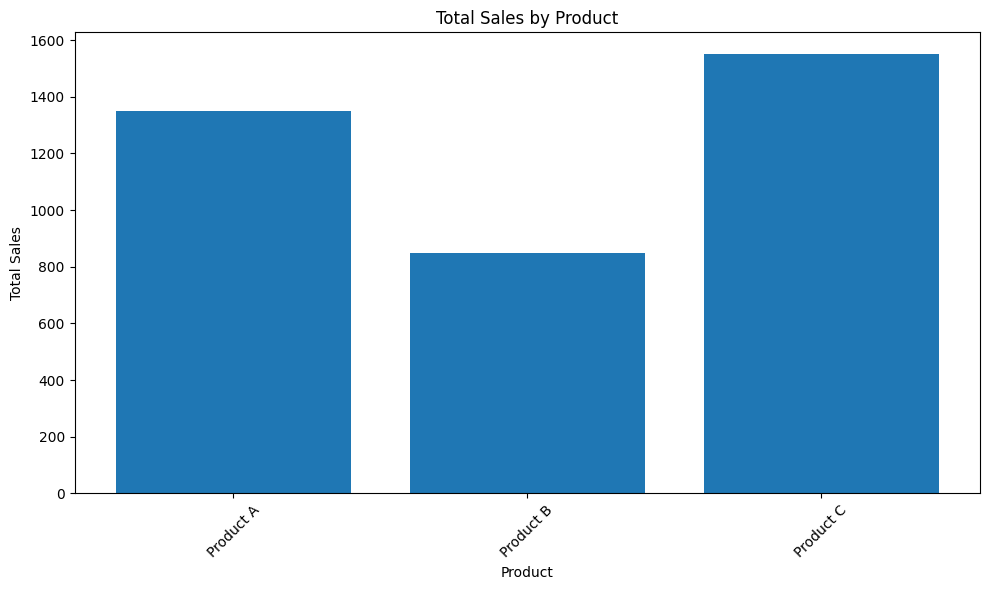



Line plot:



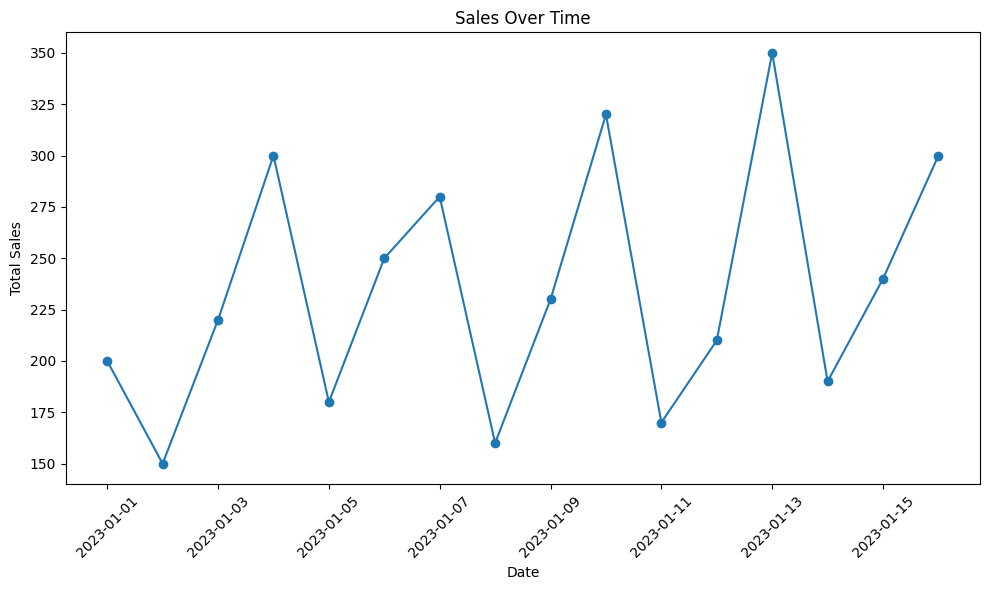



Pivot table:

Product  Product A  Product B  Product C
Region                                  
East             0          0        930
North         1350          0          0
South            0        500          0
West             0        350        620


Correlation matrix:

             Sales  Quantity
Sales     1.000000  0.926565
Quantity  0.926565  1.000000


Heatmap of the correlation matrix:



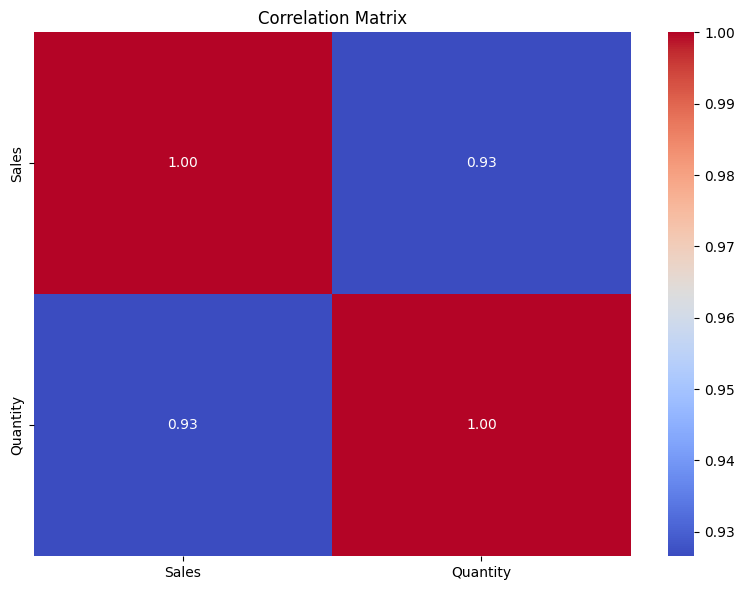

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Load the data into a pandas DataFrame
print("\n\nOriginal DataFrame:\n")
df = pd.read_csv("sales_data.csv")
print(df)

# Display the first 5 rows
print("\n\nFirst 5 rows of the DataFrame:\n")
print(df.head())

# Check for missing values
print("\n\nCount of missing values in each column:\n")
print(df.isnull().sum())

# Fill missing Sales values with the mean
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

# Drop rows with missing Product, Quantity, or Region
df = df.dropna(subset=["Product", "Quantity", "Region"])

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows where Date could not be converted
df = df.dropna(subset=["Date"])

# Display summary statistics
print("\n\nDataset after applying preprocessing techniques:\n")
print(df.describe())

# Group by Product and calculate total Sales and Quantity
product_summary = df.groupby("Product").agg({
    "Sales": "sum",
    "Quantity": "sum"
}).reset_index()

print("\n\nProduct summary after aggregation:\n")
print(product_summary)

# Bar plot of total sales by product
print("\n\nBar plot:\n")
plt.figure(figsize=(10, 6))
plt.bar(product_summary["Product"], product_summary["Sales"])
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Line plot of sales over time
print("\n\nLine plot:\n")
sales_over_time = df.groupby("Date").agg({
    "Sales": "sum"
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(
    sales_over_time["Date"],
    sales_over_time["Sales"],
    marker="o"
)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pivot table to analyze sales by Region and Product
print("\n\nPivot table:\n")
pivot_table = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)
print(pivot_table)

# Correlation matrix using numeric columns only
print("\n\nCorrelation matrix:\n")
correlation_matrix = df.select_dtypes(
    include="number"
).corr()

print(correlation_matrix)

# Heatmap of the correlation matrix
print("\n\nHeatmap of the correlation matrix:\n")
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
